In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, accuracy_score

# Source data
COMPETITIVE = [
    'FIFA World Cup', 'FIFA World Cup qualification',
    'UEFA Euro', 'UEFA Euro qualification',
    'Copa América', 'African Cup of Nations',
    'AFC Asian Cup', 'Gold Cup',
    'UEFA Nations League', 'CONCACAF Nations League',
]

# Load all historical results (for trend computation)
results = pd.read_csv('../data/processed/results_historical.csv', parse_dates=['date'])
df_comp = results[results['tournament'].isin(COMPETITIVE)].sort_values('date').reset_index(drop=True)

# Load features built in 01_EDA
features = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])

print('results_historical competitive:', len(df_comp))
print('features.csv shape:', features.shape)

results_historical competitive: 16610
features.csv shape: (16610, 17)


---
## Feature 1 — Goals Form Trend

**Hypothesis:** A team that scored 0–1–0–2–3 in its last 5 games is in better shape
than one that scored 3–2–1–0–1, even if both averaged the same.

**Implementation:** For each match, take the last 10 goals-scored values for the team
(as home or away) before that match date, fit a degree-1 polynomial (numpy polyfit),
and return the slope.
Positive slope = team is scoring more recently. Return `0.0` if fewer than 5 prior matches.

**New columns:** `home_goals_trend`, `away_goals_trend`  
**Saved to:** `data/processed/features_v2.csv`

In [2]:
def get_goals_trend(team: str, date: pd.Timestamp, n: int = 10, min_matches: int = 5) -> float:
    """Linear regression slope on goals scored in last N matches before date.
    Positive = improving, negative = declining, 0.0 = insufficient history.
    """
    mask = (
        ((df_comp['home_team'] == team) | (df_comp['away_team'] == team)) &
        (df_comp['date'] < date)
    )
    recent = df_comp[mask].tail(n)

    if len(recent) < min_matches:
        return 0.0

    goals = [
        row['home_score'] if row['home_team'] == team else row['away_score']
        for _, row in recent.iterrows()
    ]

    x = np.arange(len(goals))
    slope = np.polyfit(x, goals, 1)[0]
    return float(slope)


# Quick sanity check
slope = get_goals_trend('Brazil', pd.Timestamp('2022-11-20'))
print(f'Brazil trend before WC 2022: {slope:.3f}')

Brazil trend before WC 2022: 0.212


In [3]:
# This cell takes ~3-5 minutes (16,610 rows × 2 teams)
from tqdm.auto import tqdm
tqdm.pandas()

home_trends = []
away_trends = []

for _, row in tqdm(features.iterrows(), total=len(features), desc='Computing trends'):
    home_trends.append(get_goals_trend(row['home_team'], row['date']))
    away_trends.append(get_goals_trend(row['away_team'], row['date']))

features_v2 = features.copy()
features_v2['home_goals_trend'] = home_trends
features_v2['away_goals_trend'] = away_trends

print('features_v2 shape:', features_v2.shape)
print(features_v2[['home_goals_trend', 'away_goals_trend']].describe())

/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Computing trends: 100%|██████████| 16610/16610 [02:18<00:00, 120.21it/s]

features_v2 shape: (16610, 19)
       home_goals_trend  away_goals_trend
count      16610.000000      16610.000000
mean          -0.002661          0.002055
std            0.176613          0.173244
min           -1.900000         -2.339394
25%           -0.094156         -0.090909
50%            0.000000          0.000000
75%            0.090909          0.096970
max            1.557576          1.571429


home_goals_trend = 0.0 (insufficient history): 611 (3.7%)
away_goals_trend = 0.0 (insufficient history): 667 (4.0%)


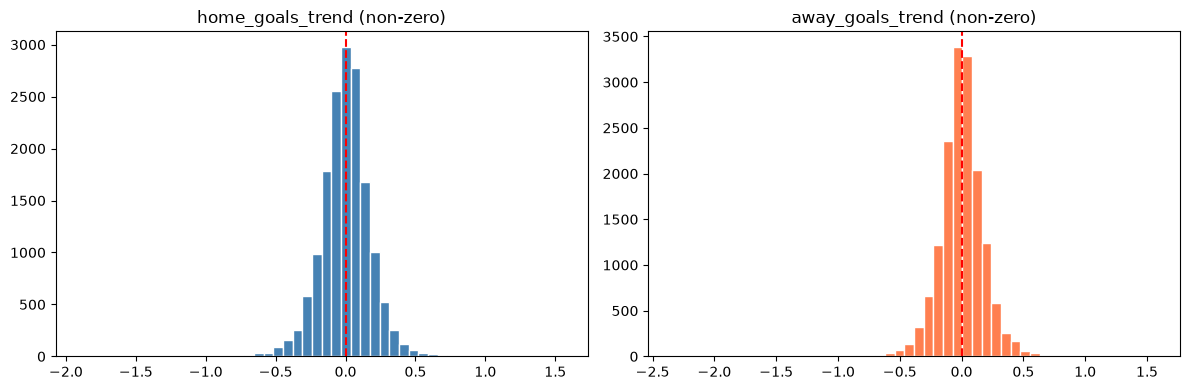

Non-zero slope range: [-1.90, 1.56]


In [4]:
# How many rows hit the min_matches=5 default (0.0)?
zeros_h = (features_v2['home_goals_trend'] == 0.0).sum()
zeros_a = (features_v2['away_goals_trend'] == 0.0).sum()
print(f'home_goals_trend = 0.0 (insufficient history): {zeros_h} ({zeros_h/len(features_v2):.1%})')
print(f'away_goals_trend = 0.0 (insufficient history): {zeros_a} ({zeros_a/len(features_v2):.1%})')

# Distribution of slopes
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
non_zero_h = features_v2[features_v2['home_goals_trend'] != 0.0]['home_goals_trend']
non_zero_a = features_v2[features_v2['away_goals_trend'] != 0.0]['away_goals_trend']

axes[0].hist(non_zero_h, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('home_goals_trend (non-zero)')
axes[0].axvline(0, color='red', linestyle='--')

axes[1].hist(non_zero_a, bins=50, color='coral', edgecolor='white')
axes[1].set_title('away_goals_trend (non-zero)')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()
print(f'Non-zero slope range: [{non_zero_h.min():.2f}, {non_zero_h.max():.2f}]')

In [5]:
features_v2.to_csv('../data/processed/features_v2.csv', index=False)
print('Saved features_v2.csv:', features_v2.shape)

Saved features_v2.csv: (16610, 19)


In [6]:
RESULT_MAP = {'home_win': 0, 'draw': 1, 'away_win': 2}

FEATURE_COLS_V1 = [
    'home_win_rate', 'home_draw_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded',
    'away_win_rate', 'away_draw_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded',
    'elo_diff', 'neutral', 'tournament',
]

FEATURE_COLS_V2 = FEATURE_COLS_V1 + ['home_goals_trend', 'away_goals_trend']

# Time-based split — same as 02_model.ipynb
train = features_v2[features_v2['date'] < '2022-11-20'].copy()
val   = features_v2[
    (features_v2['date'] >= '2022-11-20') &
    (features_v2['date'] <= '2022-12-18') &
    (features_v2['tournament'] == 'FIFA World Cup')
].copy()
test  = features_v2[features_v2['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

# Encode tournament
le = LabelEncoder()
le.fit(features_v2['tournament'])

for df in (train, val, test):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

# --- Baseline model (V1 — without trend) ---
xgb_v1 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1.fit(
    train[FEATURE_COLS_V1], train['label'],
    eval_set=[(val[FEATURE_COLS_V1], val['label'])],
    verbose=False,
)

# --- New model (V2 — with trend) ---
xgb_v2 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v2.fit(
    train[FEATURE_COLS_V2], train['label'],
    eval_set=[(val[FEATURE_COLS_V2], val['label'])],
    verbose=False,
)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [18:33:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [18:33:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


In [7]:
def evaluate(model, X_val, X_test, y_val, y_test):
    p_val  = model.predict_proba(X_val)
    p_test = model.predict_proba(X_test)
    return {
        'val_logloss':  log_loss(y_val,  p_val),
        'test_logloss': log_loss(y_test, p_test),
        'val_acc':      accuracy_score(y_val,  p_val.argmax(axis=1)),
        'test_acc':     accuracy_score(y_test, p_test.argmax(axis=1)),
        'best_iter':    model.best_iteration,
    }

r_v1 = evaluate(xgb_v1, val[FEATURE_COLS_V1], test[FEATURE_COLS_V1], val['label'], test['label'])
r_v2 = evaluate(xgb_v2, val[FEATURE_COLS_V2], test[FEATURE_COLS_V2], val['label'], test['label'])

print('='*55)
print(f'{"Metric":<22} {"XGB v1 (11 feats)":>15} {"XGB v2 (+trend)":>15}')
print('-'*55)
print(f'{"Val log loss":<22} {r_v1["val_logloss"]:>15.4f} {r_v2["val_logloss"]:>15.4f}')
print(f'{"Test log loss":<22} {r_v1["test_logloss"]:>15.4f} {r_v2["test_logloss"]:>15.4f}')
print(f'{"Val accuracy":<22} {r_v1["val_acc"]:>15.1%} {r_v2["val_acc"]:>15.1%}')
print(f'{"Test accuracy":<22} {r_v1["test_acc"]:>15.1%} {r_v2["test_acc"]:>15.1%}')
print(f'{"Best iteration":<22} {r_v1["best_iter"]:>15} {r_v2["best_iter"]:>15}')
print('='*55)

delta_val  = r_v2['val_logloss']  - r_v1['val_logloss']
delta_test = r_v2['test_logloss'] - r_v1['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({'better' if delta_val < 0 else 'worse'})')
print(f'Δ test log loss: {delta_test:+.4f}  ({'better' if delta_test < 0 else 'worse'})')

Metric                 XGB v1 (11 feats) XGB v2 (+trend)
-------------------------------------------------------
Val log loss                    1.0189          1.0232
Test log loss                   0.9843          0.9826
Val accuracy                     46.9%           46.9%
Test accuracy                    53.6%           57.1%
Best iteration                      87              55

Δ val log loss:  +0.0043  (worse)
Δ test log loss: -0.0016  (better)


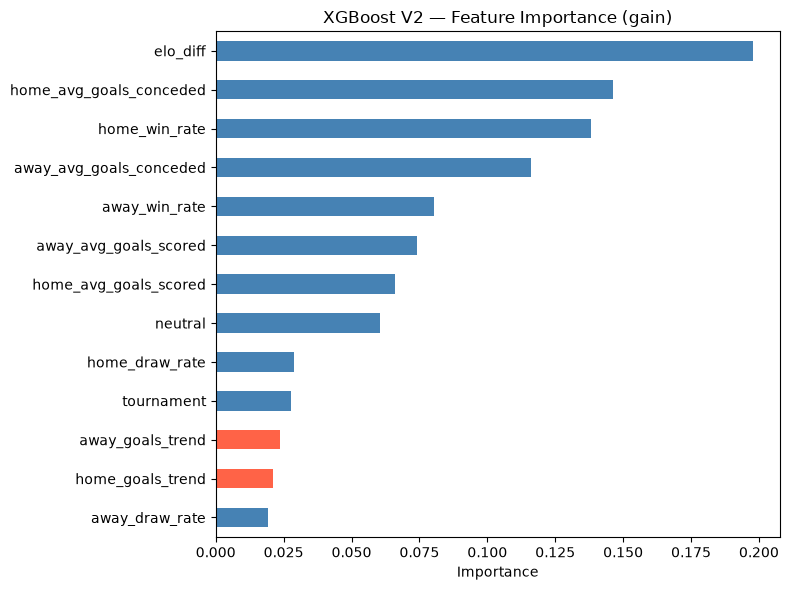


Trend features rank:
   1. elo_diff                            0.1979
   2. home_avg_goals_conceded             0.1464
   3. home_win_rate                       0.1380
   4. away_avg_goals_conceded             0.1161
   5. away_win_rate                       0.0803
   6. away_avg_goals_scored               0.0742
   7. home_avg_goals_scored               0.0660
   8. neutral                             0.0606
   9. home_draw_rate                      0.0289
  10. tournament                          0.0278
  11. away_goals_trend                    0.0237 ← trend
  12. home_goals_trend                    0.0209 ← trend
  13. away_draw_rate                      0.0192


In [8]:
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_v2.feature_importances_,
    index=FEATURE_COLS_V2
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'trend' in name else 'steelblue' for name in importance.index]
importance.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V2 — Feature Importance (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTrend features rank:')
ranked = importance.sort_values(ascending=False)
for i, (name, val) in enumerate(ranked.items(), 1):
    marker = ' ← trend' if 'trend' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 2 — Days Since Last Match (Rest / Fatigue)

**Hypothesis:** At a World Cup, teams play every 3–4 days.
A team with 7 days rest has a real advantage over one playing its third game in 9 days.

**Implementation:** For each match, find the most recent prior competitive match
for each team before the current match date. Return the number of days elapsed.
If no prior match exists, return `30` (well-rested default).

**New columns:** `home_days_rest`, `away_days_rest`  
**Saved to:** `data/processed/features_v3.csv`  
**Note:** Uses binary search per team — fast O(n log n) total.

In [9]:
from bisect import bisect_left

# Pre-build sorted date list per team (fast lookup)
_team_dates: dict[str, list] = {}
for _, row in df_comp.iterrows():
    for col in ('home_team', 'away_team'):
        t = row[col]
        if t not in _team_dates:
            _team_dates[t] = []
        _team_dates[t].append(row['date'])
for t in _team_dates:
    _team_dates[t].sort()


def get_days_rest(team: str, date: pd.Timestamp, default: int = 30) -> int:
    """Days since the team's last competitive match before `date`."""
    dates = _team_dates.get(team, [])
    idx = bisect_left(dates, date) - 1
    if idx < 0:
        return default
    return int((date - dates[idx]).days)


# Sanity checks
print('Brazil before WC 2022 final (2022-12-18):',
      get_days_rest('Brazil', pd.Timestamp('2022-12-18')), 'days')
print('France before WC 2022 final (2022-12-18):',
      get_days_rest('France', pd.Timestamp('2022-12-18')), 'days')
print('Unknown team:', get_days_rest('Atlantis', pd.Timestamp('2022-01-01')), '(default)')

Brazil before WC 2022 final (2022-12-18): 9 days
France before WC 2022 final (2022-12-18): 4 days
Unknown team: 30 (default)


In [10]:
# Fast — binary search, no loop over full df per row
features_v3 = features.copy()
features_v3['home_days_rest'] = features_v3.apply(
    lambda r: get_days_rest(r['home_team'], r['date']), axis=1
)
features_v3['away_days_rest'] = features_v3.apply(
    lambda r: get_days_rest(r['away_team'], r['date']), axis=1
)

print('features_v3 shape:', features_v3.shape)
print(features_v3[['home_days_rest', 'away_days_rest']].describe())

# How often is rest == 30 (no history)?
n_default_h = (features_v3['home_days_rest'] == 30).sum()
n_default_a = (features_v3['away_days_rest'] == 30).sum()
print(f'\nhome_days_rest = 30 (default): {n_default_h} ({n_default_h/len(features_v3):.1%})')
print(f'away_days_rest = 30 (default): {n_default_a} ({n_default_a/len(features_v3):.1%})')

features_v3 shape: (16610, 19)
       home_days_rest  away_days_rest
count    16610.000000    16610.000000
mean       124.505539      123.280132
std        443.750846      435.711375
min          1.000000        1.000000
25%          4.000000        4.000000
50%         28.000000       28.000000
75%         83.000000       81.000000
max      20076.000000    19961.000000

home_days_rest = 30 (default): 310 (1.9%)
away_days_rest = 30 (default): 320 (1.9%)


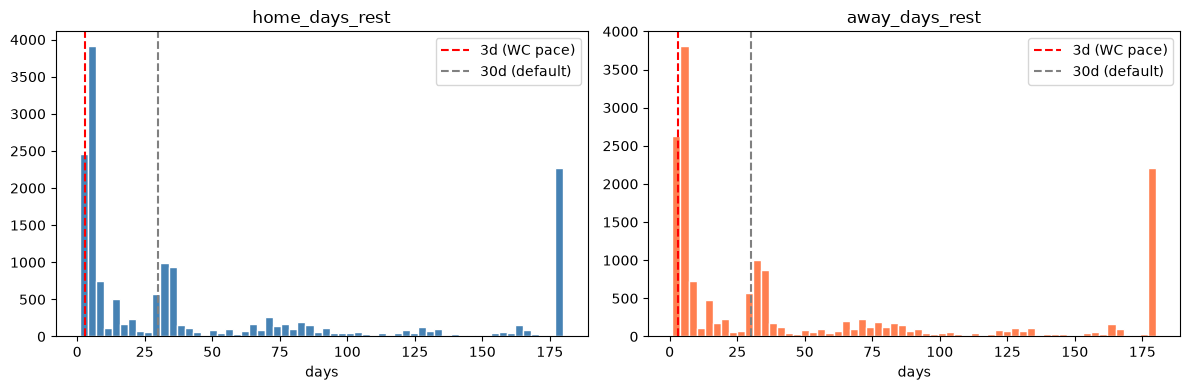


WC 2026 rest distribution:
       home_days_rest  away_days_rest
count       28.000000       28.000000
mean       214.964286      180.250000
std        117.316439      115.830216
min          5.000000        5.000000
25%        194.000000       77.000000
50%        212.500000      184.500000
75%        295.000000      252.750000
max        372.000000      448.000000


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes,
                            ['home_days_rest', 'away_days_rest'],
                            ['steelblue', 'coral']):
    data = features_v3[col].clip(upper=180)  # cap extreme outliers for display
    ax.hist(data, bins=60, color=color, edgecolor='white')
    ax.axvline(3, color='red',   linestyle='--', label='3d (WC pace)')
    ax.axvline(30, color='gray', linestyle='--', label='30d (default)')
    ax.set_title(col)
    ax.set_xlabel('days')
    ax.legend()

plt.tight_layout()
plt.show()

# WC 2026 test set — does rest vary?
test_rest = features_v3[features_v3['date'] >= '2026-06-11'][['home_team','away_team','home_days_rest','away_days_rest','date']]
print('\nWC 2026 rest distribution:')
print(test_rest[['home_days_rest','away_days_rest']].describe())

In [12]:
features_v3.to_csv('../data/processed/features_v3.csv', index=False)
print('Saved features_v3.csv:', features_v3.shape)

Saved features_v3.csv: (16610, 19)


In [13]:
FEATURE_COLS_V1 = [
    'home_win_rate', 'home_draw_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded',
    'away_win_rate', 'away_draw_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded',
    'elo_diff', 'neutral', 'tournament',
]
FEATURE_COLS_V3 = FEATURE_COLS_V1 + ['home_days_rest', 'away_days_rest']

train3 = features_v3[features_v3['date'] < '2022-11-20'].copy()
val3   = features_v3[
    (features_v3['date'] >= '2022-11-20') &
    (features_v3['date'] <= '2022-12-18') &
    (features_v3['tournament'] == 'FIFA World Cup')
].copy()
test3  = features_v3[features_v3['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train3)}, Val: {len(val3)}, Test: {len(test3)}')

le3 = LabelEncoder()
le3.fit(features_v3['tournament'])
for df in (train3, val3, test3):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le3.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

# V1 baseline (retrain on same data for fair comparison)
xgb_v1b = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1b.fit(train3[FEATURE_COLS_V1], train3['label'],
             eval_set=[(val3[FEATURE_COLS_V1], val3['label'])], verbose=False)

# V3: +days_rest
xgb_v3 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v3.fit(train3[FEATURE_COLS_V3], train3['label'],
            eval_set=[(val3[FEATURE_COLS_V3], val3['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [18:48:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [18:48:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [14]:
r_v1b = evaluate(xgb_v1b, val3[FEATURE_COLS_V1], test3[FEATURE_COLS_V1], val3['label'], test3['label'])
r_v3  = evaluate(xgb_v3,  val3[FEATURE_COLS_V3], test3[FEATURE_COLS_V3], val3['label'], test3['label'])

print('='*58)
print(f'{"Metric":<22} {"XGB v1 (11 feats)":>17} {"XGB v3 (+rest)":>15}')
print('-'*58)
print(f'{"Val log loss":<22} {r_v1b["val_logloss"]:>17.4f} {r_v3["val_logloss"]:>15.4f}')
print(f'{"Test log loss":<22} {r_v1b["test_logloss"]:>17.4f} {r_v3["test_logloss"]:>15.4f}')
print(f'{"Val accuracy":<22} {r_v1b["val_acc"]:>17.1%} {r_v3["val_acc"]:>15.1%}')
print(f'{"Test accuracy":<22} {r_v1b["test_acc"]:>17.1%} {r_v3["test_acc"]:>15.1%}')
print(f'{"Best iteration":<22} {r_v1b["best_iter"]:>17} {r_v3["best_iter"]:>15}')
print('='*58)

delta_val  = r_v3['val_logloss']  - r_v1b['val_logloss']
delta_test = r_v3['test_logloss'] - r_v1b['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

Metric                 XGB v1 (11 feats)  XGB v3 (+rest)
----------------------------------------------------------
Val log loss                      1.0189          1.0212
Test log loss                     0.9843          0.9900
Val accuracy                       46.9%           46.9%
Test accuracy                      53.6%           57.1%
Best iteration                        87              55

Δ val log loss:  +0.0023  (worse)
Δ test log loss: +0.0057  (worse)


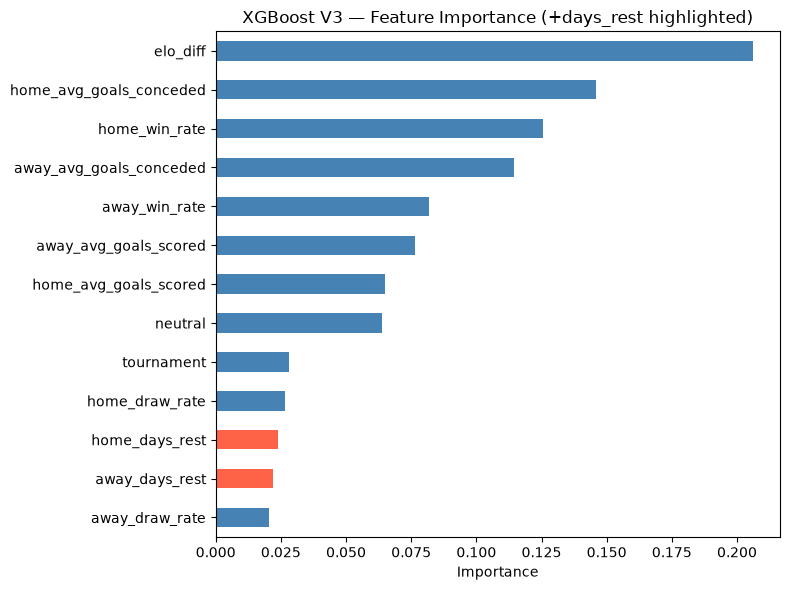


Feature importance rank:
   1. elo_diff                            0.2062
   2. home_avg_goals_conceded             0.1460
   3. home_win_rate                       0.1257
   4. away_avg_goals_conceded             0.1143
   5. away_win_rate                       0.0817
   6. away_avg_goals_scored               0.0764
   7. home_avg_goals_scored               0.0649
   8. neutral                             0.0640
   9. tournament                          0.0280
  10. home_draw_rate                      0.0265
  11. home_days_rest                      0.0241 ← rest
  12. away_days_rest                      0.0219 ← rest
  13. away_draw_rate                      0.0204


In [15]:
importance3 = pd.Series(
    xgb_v3.feature_importances_,
    index=FEATURE_COLS_V3
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'rest' in name else 'steelblue' for name in importance3.index]
importance3.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V3 — Feature Importance (+days_rest highlighted)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nFeature importance rank:')
ranked3 = importance3.sort_values(ascending=False)
for i, (name, val) in enumerate(ranked3.items(), 1):
    marker = ' ← rest' if 'rest' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 2b — Days Since Last Match, Capped at 14 days

**Hypothesis:** The original `days_rest` failed because it measured months between
tournaments (e.g. 180 days since last qualification match), not within-tournament fatigue.
Capping at 14 days maps all long rests to a neutral value,
keeping the signal only where it matters: 3–7 days within a tournament.

**Implementation:** `days_rest_capped = min(days_rest, 14)`  
Reuses `home_days_rest` / `away_days_rest` already computed in Feature 2.  
**New columns:** `home_days_rest_cap`, `away_days_rest_cap`  
**Saved to:** `data/processed/features_v4.csv`

In [16]:
# Reuse features_v3 — days_rest already computed
CAP = 14

features_v4 = features_v3.copy()
features_v4['home_days_rest_cap'] = features_v4['home_days_rest'].clip(upper=CAP)
features_v4['away_days_rest_cap'] = features_v4['away_days_rest'].clip(upper=CAP)

print('features_v4 shape:', features_v4.shape)
print(features_v4[['home_days_rest_cap', 'away_days_rest_cap']].describe())

# How many rows hit the cap (were > 14 days)?
capped_h = (features_v3['home_days_rest'] > CAP).sum()
capped_a = (features_v3['away_days_rest'] > CAP).sum()
print(f'\nRows capped home: {capped_h} ({capped_h/len(features_v4):.1%})')
print(f'Rows capped away: {capped_a} ({capped_a/len(features_v4):.1%})')

# WC 2026 test — values after cap
test_cap = features_v4[features_v4['date'] >= '2026-06-11']
print('\nWC 2026 days_rest_cap:')
print(test_cap[['home_days_rest_cap', 'away_days_rest_cap']].describe())

features_v4 shape: (16610, 21)
       home_days_rest_cap  away_days_rest_cap
count        16610.000000        16610.000000
mean             9.759422            9.712703
std              4.933715            4.966569
min              1.000000            1.000000
25%              4.000000            4.000000
50%             14.000000           14.000000
75%             14.000000           14.000000
max             14.000000           14.000000

Rows capped home: 8936 (53.8%)
Rows capped away: 8926 (53.7%)

WC 2026 days_rest_cap:
       home_days_rest_cap  away_days_rest_cap
count           28.000000           28.000000
mean            12.892857           12.892857
std              2.780078            2.780078
min              5.000000            5.000000
25%             14.000000           14.000000
50%             14.000000           14.000000
75%             14.000000           14.000000
max             14.000000           14.000000


In [17]:
features_v4.to_csv('../data/processed/features_v4.csv', index=False)
print('Saved features_v4.csv:', features_v4.shape)

Saved features_v4.csv: (16610, 21)


In [18]:
FEATURE_COLS_V4 = FEATURE_COLS_V1 + ['home_days_rest_cap', 'away_days_rest_cap']

train4 = features_v4[features_v4['date'] < '2022-11-20'].copy()
val4   = features_v4[
    (features_v4['date'] >= '2022-11-20') &
    (features_v4['date'] <= '2022-12-18') &
    (features_v4['tournament'] == 'FIFA World Cup')
].copy()
test4  = features_v4[features_v4['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train4)}, Val: {len(val4)}, Test: {len(test4)}')

le4 = LabelEncoder()
le4.fit(features_v4['tournament'])
for df in (train4, val4, test4):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le4.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

# V1 baseline
xgb_v1c = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1c.fit(train4[FEATURE_COLS_V1], train4['label'],
             eval_set=[(val4[FEATURE_COLS_V1], val4['label'])], verbose=False)

# V4: +days_rest capped
xgb_v4 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v4.fit(train4[FEATURE_COLS_V4], train4['label'],
            eval_set=[(val4[FEATURE_COLS_V4], val4['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [19:01:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [19:01:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [19]:
r_v1c = evaluate(xgb_v1c, val4[FEATURE_COLS_V1], test4[FEATURE_COLS_V1], val4['label'], test4['label'])
r_v4  = evaluate(xgb_v4,  val4[FEATURE_COLS_V4], test4[FEATURE_COLS_V4], val4['label'], test4['label'])

print('='*60)
print(f'{"Metric":<22} {"XGB v1 (baseline)":>18} {"XGB v4 (cap 14d)":>16}')
print('-'*60)
print(f'{"Val log loss":<22} {r_v1c["val_logloss"]:>18.4f} {r_v4["val_logloss"]:>16.4f}')
print(f'{"Test log loss":<22} {r_v1c["test_logloss"]:>18.4f} {r_v4["test_logloss"]:>16.4f}')
print(f'{"Val accuracy":<22} {r_v1c["val_acc"]:>18.1%} {r_v4["val_acc"]:>16.1%}')
print(f'{"Test accuracy":<22} {r_v1c["test_acc"]:>18.1%} {r_v4["test_acc"]:>16.1%}')
print(f'{"Best iteration":<22} {r_v1c["best_iter"]:>18} {r_v4["best_iter"]:>16}')
print('='*60)

delta_val  = r_v4['val_logloss']  - r_v1c['val_logloss']
delta_test = r_v4['test_logloss'] - r_v1c['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

# Summary table: all experiments
print('\n── Summary: all experiments ──')
print(f'{"Model":<28} {"Val LL":>8} {"Test LL":>9} {"BestIter":>10}')
print('-'*57)
rows = [
    ('XGB v1 (baseline, 11 feats)', r_v1c['val_logloss'], r_v1c['test_logloss'], r_v1c['best_iter']),
    ('XGB v2 (+goals_trend)',        1.0232,               0.9826,               55),
    ('XGB v3 (+days_rest raw)',      1.0212,               0.9900,               55),
    ('XGB v4 (+days_rest cap14)',   r_v4['val_logloss'],  r_v4['test_logloss'], r_v4['best_iter']),
    ('Ensemble XGB+Poisson',         1.0188,               0.9796,               '—'),
]
for name, vl, tl, bi in rows:
    print(f'{name:<28} {vl:>8.4f} {tl:>9.4f} {str(bi):>10}')

Metric                  XGB v1 (baseline) XGB v4 (cap 14d)
------------------------------------------------------------
Val log loss                       1.0189           1.0206
Test log loss                      0.9843           0.9865
Val accuracy                        46.9%            46.9%
Test accuracy                       53.6%            57.1%
Best iteration                         87               57

Δ val log loss:  +0.0018  (worse)
Δ test log loss: +0.0022  (worse)

── Summary: all experiments ──
Model                          Val LL   Test LL   BestIter
---------------------------------------------------------
XGB v1 (baseline, 11 feats)    1.0189    0.9843         87
XGB v2 (+goals_trend)          1.0232    0.9826         55
XGB v3 (+days_rest raw)        1.0212    0.9900         55
XGB v4 (+days_rest cap14)      1.0206    0.9865         57
Ensemble XGB+Poisson           1.0188    0.9796          —


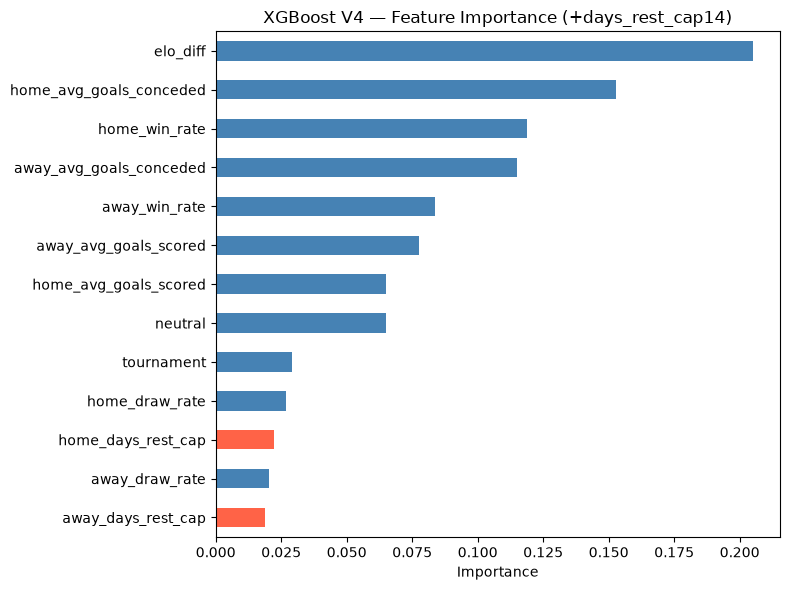

Feature importance rank:
   1. elo_diff                            0.2051
   2. home_avg_goals_conceded             0.1526
   3. home_win_rate                       0.1187
   4. away_avg_goals_conceded             0.1152
   5. away_win_rate                       0.0836
   6. away_avg_goals_scored               0.0777
   7. home_avg_goals_scored               0.0650
   8. neutral                             0.0650
   9. tournament                          0.0290
  10. home_draw_rate                      0.0267
  11. home_days_rest_cap                  0.0221 ← rest_cap
  12. away_draw_rate                      0.0205
  13. away_days_rest_cap                  0.0189 ← rest_cap


In [20]:
importance4 = pd.Series(
    xgb_v4.feature_importances_,
    index=FEATURE_COLS_V4
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'rest' in name else 'steelblue' for name in importance4.index]
importance4.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V4 — Feature Importance (+days_rest_cap14)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Feature importance rank:')
for i, (name, val) in enumerate(importance4.sort_values(ascending=False).items(), 1):
    marker = ' ← rest_cap' if 'rest' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 3 — Head-to-Head (H2H) History

**Hypothesis:** Historical matchup patterns between specific pairs of teams persist over time.
Brazil vs Germany, Argentina vs England — each pair has its own story that ELO and recent form
don't capture. A team that historically dominates its opponent should have a systematic edge.

**Implementation:** For each match, find the last 10 competitive meetings between
the same two teams (in either direction) before the match date. Compute:
- `h2h_home_win_rate` — fraction of those meetings won by the *current* home team
- `h2h_avg_goal_diff` — average goal difference (home − away) from the current home team's perspective

Fallback when fewer than 3 prior meetings: `h2h_home_win_rate=0.5`, `h2h_avg_goal_diff=0.0` (neutral).

**New columns:** `h2h_home_win_rate`, `h2h_avg_goal_diff`  
**Saved to:** `data/processed/features_v5.csv`

In [21]:
def get_h2h(home_team: str, away_team: str, date: pd.Timestamp,
             n: int = 10, min_matches: int = 3) -> pd.Series:
    """H2H win rate and avg goal diff for home_team vs away_team before date."""
    mask = (
        (
            ((df_comp['home_team'] == home_team) & (df_comp['away_team'] == away_team)) |
            ((df_comp['home_team'] == away_team) & (df_comp['away_team'] == home_team))
        ) &
        (df_comp['date'] < date)
    )
    recent = df_comp[mask].tail(n)

    if len(recent) < min_matches:
        return pd.Series({'h2h_home_win_rate': 0.5, 'h2h_avg_goal_diff': 0.0})

    home_wins = 0
    goal_diffs = []
    for _, row in recent.iterrows():
        if row['home_team'] == home_team:
            if row['outcome'] == 'home_win': home_wins += 1
            goal_diffs.append(row['home_score'] - row['away_score'])
        else:
            if row['outcome'] == 'away_win': home_wins += 1
            goal_diffs.append(row['away_score'] - row['home_score'])

    return pd.Series({
        'h2h_home_win_rate': home_wins / len(recent),
        'h2h_avg_goal_diff': float(np.mean(goal_diffs)),
    })


# Sanity checks
print('Germany vs Brazil (before WC 2014 final):')
print(get_h2h('Germany', 'Brazil', pd.Timestamp('2014-07-08')))
print()
print('Argentina vs France (before WC 2022 final):')
print(get_h2h('Argentina', 'France', pd.Timestamp('2022-12-18')))
print()
print('New pair with no history (fallback):')
print(get_h2h('Curaçao', 'Panama', pd.Timestamp('2026-06-11')))

Germany vs Brazil (before WC 2014 final):
h2h_home_win_rate    0.5
h2h_avg_goal_diff    0.0
dtype: float64

Argentina vs France (before WC 2022 final):
h2h_home_win_rate    0.666667
h2h_avg_goal_diff    0.333333
dtype: float64

New pair with no history (fallback):
h2h_home_win_rate    0.000000
h2h_avg_goal_diff   -0.666667
dtype: float64


In [22]:
# ~2-3 minutes (16,610 rows, two-team mask per row)
h2h_results = features.apply(
    lambda r: get_h2h(r['home_team'], r['away_team'], r['date']),
    axis=1
)

features_v5 = features.copy()
features_v5['h2h_home_win_rate'] = h2h_results['h2h_home_win_rate']
features_v5['h2h_avg_goal_diff'] = h2h_results['h2h_avg_goal_diff']

print('features_v5 shape:', features_v5.shape)
print(features_v5[['h2h_home_win_rate', 'h2h_avg_goal_diff']].describe())

# How often did we fall back to neutral values?
fallback = (features_v5['h2h_home_win_rate'] == 0.5) & (features_v5['h2h_avg_goal_diff'] == 0.0)
print(f'\nFallback (< 3 H2H meetings): {fallback.sum()} ({fallback.mean():.1%})')
print(f'Real H2H data:               {(~fallback).sum()} ({(~fallback).mean():.1%})')

features_v5 shape: (16610, 19)
       h2h_home_win_rate  h2h_avg_goal_diff
count       16610.000000       16610.000000
mean            0.453293           0.019858
std             0.211545           1.140056
min             0.000000         -10.000000
25%             0.400000           0.000000
50%             0.500000           0.000000
75%             0.500000           0.000000
max             1.000000           9.000000

Fallback (< 3 H2H meetings): 8843 (53.2%)
Real H2H data:               7767 (46.8%)


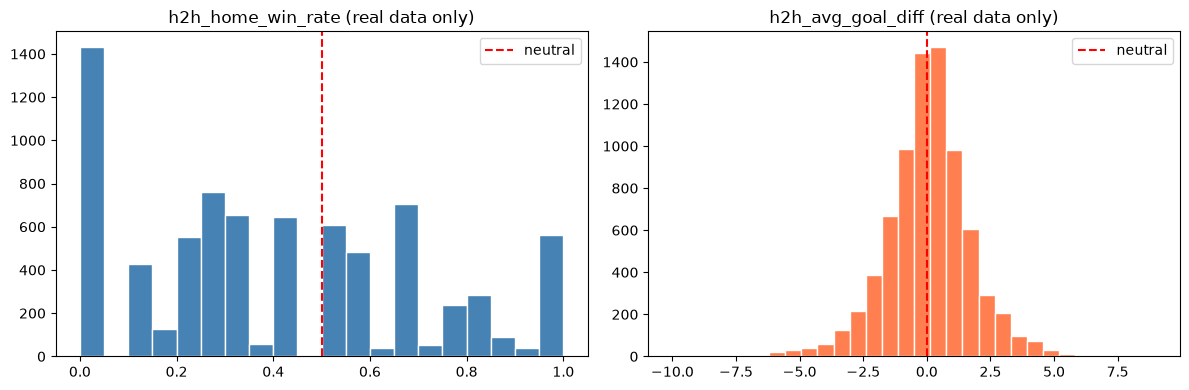

WC 2026 test: real H2H data for 3/28 matches (11%)


In [23]:
import matplotlib.pyplot as plt

real = features_v5[~((features_v5['h2h_home_win_rate'] == 0.5) &
                      (features_v5['h2h_avg_goal_diff'] == 0.0))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(real['h2h_home_win_rate'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('h2h_home_win_rate (real data only)')
axes[0].axvline(0.5, color='red', linestyle='--', label='neutral')
axes[0].legend()

axes[1].hist(real['h2h_avg_goal_diff'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('h2h_avg_goal_diff (real data only)')
axes[1].axvline(0, color='red', linestyle='--', label='neutral')
axes[1].legend()

plt.tight_layout()
plt.show()

# Check WC 2026 test set coverage
test_h2h = features_v5[features_v5['date'] >= '2026-06-11']
fallback_test = (test_h2h['h2h_home_win_rate'] == 0.5) & (test_h2h['h2h_avg_goal_diff'] == 0.0)
print(f'WC 2026 test: real H2H data for {(~fallback_test).sum()}/28 matches ({(~fallback_test).mean():.0%})')

In [24]:
features_v5.to_csv('../data/processed/features_v5.csv', index=False)
print('Saved features_v5.csv:', features_v5.shape)

Saved features_v5.csv: (16610, 19)


In [25]:
FEATURE_COLS_V5 = FEATURE_COLS_V1 + ['h2h_home_win_rate', 'h2h_avg_goal_diff']

train5 = features_v5[features_v5['date'] < '2022-11-20'].copy()
val5   = features_v5[
    (features_v5['date'] >= '2022-11-20') &
    (features_v5['date'] <= '2022-12-18') &
    (features_v5['tournament'] == 'FIFA World Cup')
].copy()
test5  = features_v5[features_v5['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train5)}, Val: {len(val5)}, Test: {len(test5)}')

le5 = LabelEncoder()
le5.fit(features_v5['tournament'])
for df in (train5, val5, test5):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le5.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

xgb_v1d = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1d.fit(train5[FEATURE_COLS_V1], train5['label'],
             eval_set=[(val5[FEATURE_COLS_V1], val5['label'])], verbose=False)

xgb_v5 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v5.fit(train5[FEATURE_COLS_V5], train5['label'],
            eval_set=[(val5[FEATURE_COLS_V5], val5['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:05:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:05:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


In [26]:
r_v1d = evaluate(xgb_v1d, val5[FEATURE_COLS_V1], test5[FEATURE_COLS_V1], val5['label'], test5['label'])
r_v5  = evaluate(xgb_v5,  val5[FEATURE_COLS_V5], test5[FEATURE_COLS_V5], val5['label'], test5['label'])

print('='*60)
print(f'{"Metric":<22} {"XGB v1 (baseline)":>18} {"XGB v5 (+H2H)":>16}')
print('-'*60)
print(f'{"Val log loss":<22} {r_v1d["val_logloss"]:>18.4f} {r_v5["val_logloss"]:>16.4f}')
print(f'{"Test log loss":<22} {r_v1d["test_logloss"]:>18.4f} {r_v5["test_logloss"]:>16.4f}')
print(f'{"Val accuracy":<22} {r_v1d["val_acc"]:>18.1%} {r_v5["val_acc"]:>16.1%}')
print(f'{"Test accuracy":<22} {r_v1d["test_acc"]:>18.1%} {r_v5["test_acc"]:>16.1%}')
print(f'{"Best iteration":<22} {r_v1d["best_iter"]:>18} {r_v5["best_iter"]:>16}')
print('='*60)

delta_val  = r_v5['val_logloss']  - r_v1d['val_logloss']
delta_test = r_v5['test_logloss'] - r_v1d['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

print('\n── Summary: all experiments ──')
print(f'{"Model":<30} {"Val LL":>8} {"Test LL":>9} {"BestIter":>10}')
print('-'*59)
rows = [
    ('XGB v1 (baseline, 11 feats)',  r_v1d['val_logloss'], r_v1d['test_logloss'], r_v1d['best_iter']),
    ('XGB v2 (+goals_trend)',         1.0232,               0.9826,               55),
    ('XGB v3 (+days_rest raw)',       1.0212,               0.9900,               55),
    ('XGB v4 (+days_rest cap14)',     1.0206,               0.9865,               57),
    ('XGB v5 (+H2H)',                r_v5['val_logloss'],  r_v5['test_logloss'],  r_v5['best_iter']),
    ('Ensemble XGB+Poisson',          1.0188,               0.9796,               '—'),
]
for name, vl, tl, bi in rows:
    print(f'{name:<30} {vl:>8.4f} {tl:>9.4f} {str(bi):>10}')

Metric                  XGB v1 (baseline)    XGB v5 (+H2H)
------------------------------------------------------------
Val log loss                       1.0189           1.0128
Test log loss                      0.9843           0.9742
Val accuracy                        46.9%            46.9%
Test accuracy                       53.6%            53.6%
Best iteration                         87               90

Δ val log loss:  -0.0061  (better)
Δ test log loss: -0.0101  (better)

── Summary: all experiments ──
Model                            Val LL   Test LL   BestIter
-----------------------------------------------------------
XGB v1 (baseline, 11 feats)      1.0189    0.9843         87
XGB v2 (+goals_trend)            1.0232    0.9826         55
XGB v3 (+days_rest raw)          1.0212    0.9900         55
XGB v4 (+days_rest cap14)        1.0206    0.9865         57
XGB v5 (+H2H)                    1.0128    0.9742         90
Ensemble XGB+Poisson             1.0188    0.9796       

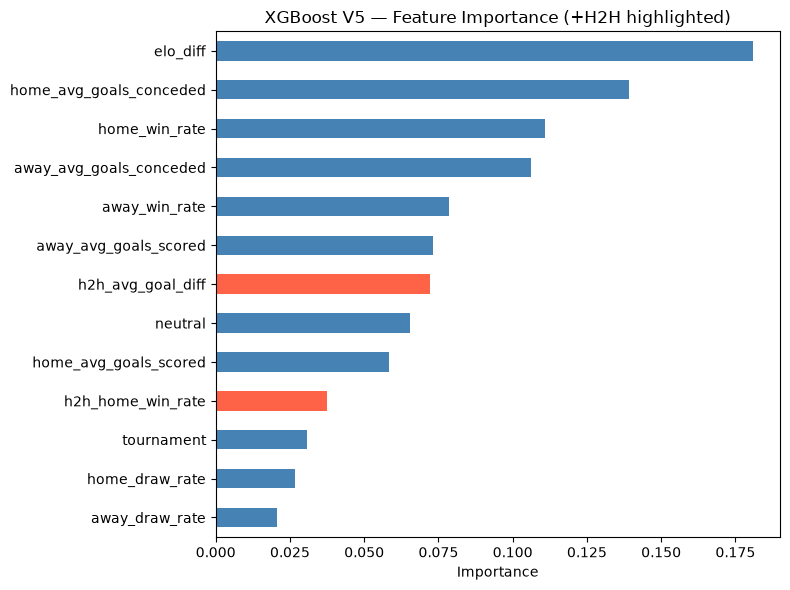

Feature importance rank:
   1. elo_diff                            0.1810
   2. home_avg_goals_conceded             0.1391
   3. home_win_rate                       0.1108
   4. away_avg_goals_conceded             0.1063
   5. away_win_rate                       0.0787
   6. away_avg_goals_scored               0.0733
   7. h2h_avg_goal_diff                   0.0722 ← H2H
   8. neutral                             0.0653
   9. home_avg_goals_scored               0.0582
  10. h2h_home_win_rate                   0.0374 ← H2H
  11. tournament                          0.0306
  12. home_draw_rate                      0.0267
  13. away_draw_rate                      0.0206


In [28]:
importance5 = pd.Series(
    xgb_v5.feature_importances_,
    index=FEATURE_COLS_V5
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'h2h' in name else 'steelblue' for name in importance5.index]
importance5.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V5 — Feature Importance (+H2H highlighted)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Feature importance rank:')
for i, (name, val) in enumerate(importance5.sort_values(ascending=False).items(), 1):
    marker = ' ← H2H' if 'h2h' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 4 — ELO Momentum (тренд рейтинга)

**Hypothesis:** A team with ELO 1800 that was at 1750 six months ago is in a different
state than one that was at 1850. The current `elo_diff` captures the snapshot,
but not the trajectory. Rising ELO = improving form; falling ELO = declining.

**Implementation:** `features.csv` already contains `home_elo` and `away_elo`
at the time of each match. From these we reconstruct each team's ELO history.
For each match we find the team's ELO 180 days earlier (binary search) and compute:

```
elo_momentum = elo_now - elo_180_days_ago
```

Positive = team is rising, negative = declining. Return `0.0` if no data 180 days back.

**New columns:** `home_elo_momentum`, `away_elo_momentum`  
**Saved to:** `data/processed/features_v6.csv`  
**Note:** Binary search on pre-built ELO history — fast, no full DataFrame scan.

In [29]:
from bisect import bisect_left

# Reconstruct per-team ELO history from features.csv (already loaded)
elo_history = pd.concat([
    features[['date','home_team','home_elo']].rename(columns={'home_team':'team','home_elo':'elo'}),
    features[['date','away_team','away_elo']].rename(columns={'away_team':'team','away_elo':'elo'}),
]).sort_values(['team','date']).reset_index(drop=True)

_team_elo: dict = {}
for team, grp in elo_history.groupby('team'):
    _team_elo[team] = {
        'dates': grp['date'].tolist(),
        'elos':  grp['elo'].tolist(),
    }


def get_elo_momentum(team: str, date: pd.Timestamp,
                     current_elo: float, window_days: int = 180) -> float:
    """ELO change over the past window_days. 0.0 if no historical data."""
    entry = _team_elo.get(team)
    if entry is None:
        return 0.0
    target = date - pd.Timedelta(days=window_days)
    idx = bisect_left(entry['dates'], target) - 1
    if idx < 0:
        return 0.0
    return current_elo - entry['elos'][idx]


# Sanity checks — teams with known momentum before WC 2022
print('Morocco before WC 2022 (should be rising — qualified dramatically):')
# Need to get Morocco ELO at WC 2022 start
wc22 = features[
    (features['date'] >= '2022-11-20') & (features['tournament'] == 'FIFA World Cup')
].head(5)
for _, row in wc22.iterrows():
    hm = get_elo_momentum(row['home_team'], row['date'], row['home_elo'])
    am = get_elo_momentum(row['away_team'], row['date'], row['away_elo'])
    print(f'  {row["home_team"]}: {hm:+.1f}  |  {row["away_team"]}: {am:+.1f}')

Morocco before WC 2022 (should be rising — qualified dramatically):
  Qatar: +25.0  |  Ecuador: +0.0
  Senegal: +0.0  |  Netherlands: -65.0
  England: +70.0  |  Iran: +0.0
  USA: +0.0  |  Wales: +0.0
  Argentina: +0.0  |  Saudi Arabia: +0.0


In [30]:
# Fast — binary search, seconds not minutes
features_v6 = features.copy()
features_v6['home_elo_momentum'] = features_v6.apply(
    lambda r: get_elo_momentum(r['home_team'], r['date'], r['home_elo']), axis=1
)
features_v6['away_elo_momentum'] = features_v6.apply(
    lambda r: get_elo_momentum(r['away_team'], r['date'], r['away_elo']), axis=1
)

print('features_v6 shape:', features_v6.shape)
print(features_v6[['home_elo_momentum', 'away_elo_momentum']].describe())

zeros_h = (features_v6['home_elo_momentum'] == 0.0).sum()
zeros_a = (features_v6['away_elo_momentum'] == 0.0).sum()
print(f'\nhome_elo_momentum = 0.0 (no 180d history): {zeros_h} ({zeros_h/len(features_v6):.1%})')
print(f'away_elo_momentum = 0.0 (no 180d history): {zeros_a} ({zeros_a/len(features_v6):.1%})')

# WC 2026 test set
test6 = features_v6[features_v6['date'] >= '2026-06-11']
print('\nWC 2026 ELO momentum:')
print(test6[['home_elo_momentum', 'away_elo_momentum']].describe())

features_v6 shape: (16610, 19)
       home_elo_momentum  away_elo_momentum
count       16610.000000       16610.000000
mean            1.613907           1.462553
std            35.188953          34.168872
min          -296.000000        -296.000000
25%             0.000000           0.000000
50%             0.000000           0.000000
75%             0.000000           0.000000
max           345.000000         345.000000

home_elo_momentum = 0.0 (no 180d history): 11017 (66.3%)
away_elo_momentum = 0.0 (no 180d history): 11425 (68.8%)

WC 2026 ELO momentum:
       home_elo_momentum  away_elo_momentum
count          28.000000          28.000000
mean            5.964286          35.035714
std            49.509058          57.295519
min           -99.000000         -99.000000
25%           -17.250000          -1.250000
50%             6.000000          33.500000
75%            48.750000          84.000000
max            83.000000         131.000000


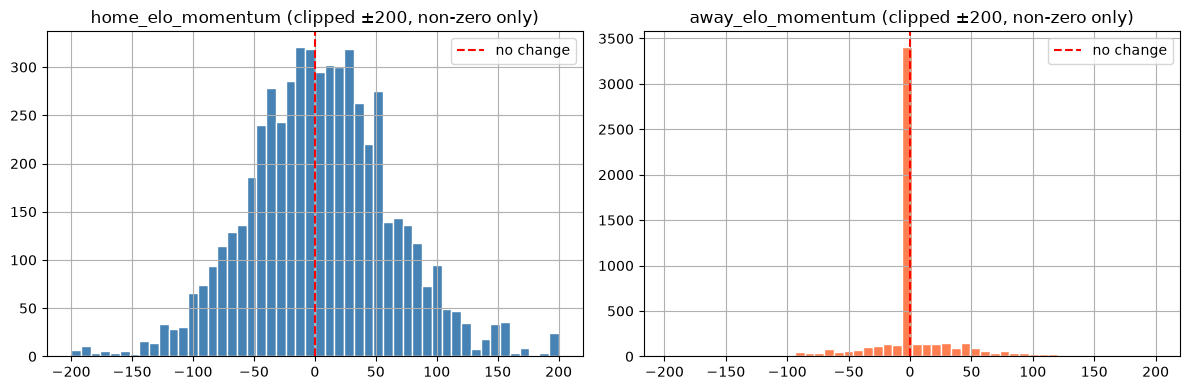

Top 5 rising teams at WC 2026 (avg ELO momentum):
team
Curaçao       131.0
DR Congo      117.0
Norway        116.0
Türkiye       106.0
Cape Verde     89.0
Name: momentum, dtype: float64

Top 5 falling teams at WC 2026:
team
Uruguay   -58.0
Germany   -61.0
Iran      -83.0
Sweden    -84.0
Qatar     -99.0
Name: momentum, dtype: float64


In [31]:
import matplotlib.pyplot as plt

non_zero = features_v6[features_v6['home_elo_momentum'] != 0.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes,
    ['home_elo_momentum', 'away_elo_momentum'], ['steelblue', 'coral']):
    non_zero[col].clip(-200, 200).hist(bins=50, ax=ax, color=color, edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', label='no change')
    ax.set_title(f'{col} (clipped ±200, non-zero only)')
    ax.legend()

plt.tight_layout()
plt.show()

# Top rising/falling teams in WC 2026
t = features_v6[features_v6['date'] >= '2026-06-11'].copy()
rising  = pd.concat([
    t[['home_team','home_elo_momentum']].rename(columns={'home_team':'team','home_elo_momentum':'momentum'}),
    t[['away_team','away_elo_momentum']].rename(columns={'away_team':'team','away_elo_momentum':'momentum'}),
]).groupby('team')['momentum'].mean().sort_values(ascending=False)
print('Top 5 rising teams at WC 2026 (avg ELO momentum):')
print(rising.head())
print('\nTop 5 falling teams at WC 2026:')
print(rising.tail())

In [32]:
features_v6.to_csv('../data/processed/features_v6.csv', index=False)
print('Saved features_v6.csv:', features_v6.shape)

Saved features_v6.csv: (16610, 19)


In [33]:
FEATURE_COLS_V6 = FEATURE_COLS_V1 + ['home_elo_momentum', 'away_elo_momentum']

train6 = features_v6[features_v6['date'] < '2022-11-20'].copy()
val6   = features_v6[
    (features_v6['date'] >= '2022-11-20') &
    (features_v6['date'] <= '2022-12-18') &
    (features_v6['tournament'] == 'FIFA World Cup')
].copy()
test6  = features_v6[features_v6['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train6)}, Val: {len(val6)}, Test: {len(test6)}')

le6 = LabelEncoder()
le6.fit(features_v6['tournament'])
for df in (train6, val6, test6):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le6.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

xgb_v1e = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1e.fit(train6[FEATURE_COLS_V1], train6['label'],
             eval_set=[(val6[FEATURE_COLS_V1], val6['label'])], verbose=False)

xgb_v6 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v6.fit(train6[FEATURE_COLS_V6], train6['label'],
            eval_set=[(val6[FEATURE_COLS_V6], val6['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:26:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:26:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


In [34]:
r_v1e = evaluate(xgb_v1e, val6[FEATURE_COLS_V1], test6[FEATURE_COLS_V1], val6['label'], test6['label'])
r_v6  = evaluate(xgb_v6,  val6[FEATURE_COLS_V6], test6[FEATURE_COLS_V6], val6['label'], test6['label'])

print('='*62)
print(f'{"Metric":<22} {"XGB v1 (baseline)":>18} {"XGB v6 (+ELO mom)":>18}')
print('-'*62)
print(f'{"Val log loss":<22} {r_v1e["val_logloss"]:>18.4f} {r_v6["val_logloss"]:>18.4f}')
print(f'{"Test log loss":<22} {r_v1e["test_logloss"]:>18.4f} {r_v6["test_logloss"]:>18.4f}')
print(f'{"Val accuracy":<22} {r_v1e["val_acc"]:>18.1%} {r_v6["val_acc"]:>18.1%}')
print(f'{"Test accuracy":<22} {r_v1e["test_acc"]:>18.1%} {r_v6["test_acc"]:>18.1%}')
print(f'{"Best iteration":<22} {r_v1e["best_iter"]:>18} {r_v6["best_iter"]:>18}')
print('='*62)

delta_val  = r_v6['val_logloss']  - r_v1e['val_logloss']
delta_test = r_v6['test_logloss'] - r_v1e['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

print('\n── Summary: all experiments ──')
print(f'{"Model":<32} {"Val LL":>8} {"Test LL":>9} {"BestIter":>10}')
print('-'*61)
rows = [
    ('XGB v1 (baseline, 11 feats)',   r_v1e['val_logloss'], r_v1e['test_logloss'], r_v1e['best_iter']),
    ('XGB v2 (+goals_trend)',          1.0232,               0.9826,               55),
    ('XGB v3 (+days_rest raw)',        1.0212,               0.9900,               55),
    ('XGB v4 (+days_rest cap14)',      1.0206,               0.9865,               57),
    ('XGB v5 (+H2H)',                  1.0128,               0.9742,               90),
    ('XGB v6 (+ELO momentum)',        r_v6['val_logloss'],  r_v6['test_logloss'],  r_v6['best_iter']),
    ('Ensemble XGB+Poisson (prod)',    1.0188,               0.9796,               '—'),
]
for name, vl, tl, bi in rows:
    print(f'{name:<32} {vl:>8.4f} {tl:>9.4f} {str(bi):>10}')

Metric                  XGB v1 (baseline)  XGB v6 (+ELO mom)
--------------------------------------------------------------
Val log loss                       1.0189             1.0215
Test log loss                      0.9843             0.9861
Val accuracy                        46.9%              45.3%
Test accuracy                       53.6%              57.1%
Best iteration                         87                 62

Δ val log loss:  +0.0027  (worse)
Δ test log loss: +0.0019  (worse)

── Summary: all experiments ──
Model                              Val LL   Test LL   BestIter
-------------------------------------------------------------
XGB v1 (baseline, 11 feats)        1.0189    0.9843         87
XGB v2 (+goals_trend)              1.0232    0.9826         55
XGB v3 (+days_rest raw)            1.0212    0.9900         55
XGB v4 (+days_rest cap14)          1.0206    0.9865         57
XGB v5 (+H2H)                      1.0128    0.9742         90
XGB v6 (+ELO momentum)        

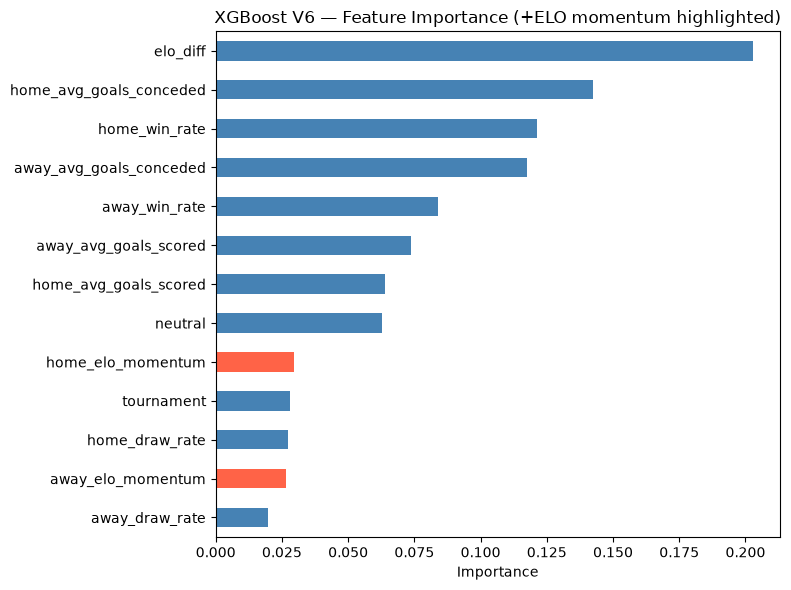

Feature importance rank:
   1. elo_diff                            0.2029
   2. home_avg_goals_conceded             0.1424
   3. home_win_rate                       0.1215
   4. away_avg_goals_conceded             0.1177
   5. away_win_rate                       0.0838
   6. away_avg_goals_scored               0.0736
   7. home_avg_goals_scored               0.0639
   8. neutral                             0.0629
   9. home_elo_momentum                   0.0297 ← ELO mom
  10. tournament                          0.0282
  11. home_draw_rate                      0.0273
  12. away_elo_momentum                   0.0265 ← ELO mom
  13. away_draw_rate                      0.0199


In [35]:
importance6 = pd.Series(
    xgb_v6.feature_importances_,
    index=FEATURE_COLS_V6
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'momentum' in name else 'steelblue' for name in importance6.index]
importance6.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V6 — Feature Importance (+ELO momentum highlighted)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Feature importance rank:')
for i, (name, val) in enumerate(importance6.sort_values(ascending=False).items(), 1):
    marker = ' ← ELO mom' if 'momentum' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 5 — Clean Sheet Rate

**Hypothesis:** `avg_goals_conceded` captures the average, but 'zero' is special in football.
A team that concedes 0–0–0–2–2 has the same average (0.8) as one that concedes 1–1–1–1–0,
but the first team has 3 clean sheets — it has a different defensive profile.
Clean sheets signal an organised, hard-to-break-down defence, which matters especially
in knockout-style high-pressure matches.

**Implementation:** For each match, count the fraction of the team's last 10 competitive
matches (before the match date) where they conceded exactly 0 goals.
Fallback to 0.22 (global average) when fewer than 3 prior matches exist.

**New columns:** `home_clean_sheet_rate`, `away_clean_sheet_rate`  
**Saved to:** `data/processed/features_v7.csv`

In [37]:
# Compute global average clean sheet rate from data (no hardcoding)
_home_cs = (df_comp["away_score"] == 0).mean()
_away_cs = (df_comp["home_score"] == 0).mean()
_CS_FALLBACK = round((_home_cs + _away_cs) / 2, 3)
print(f"Global avg clean sheet rate: home={_home_cs:.3f}, away={_away_cs:.3f}, fallback={_CS_FALLBACK}")


def get_clean_sheet_rate(team: str, date: pd.Timestamp,
                          n: int = 10, min_matches: int = 3) -> float:
    """Fraction of last N matches where the team conceded 0 goals."""
    mask = (
        ((df_comp["home_team"] == team) | (df_comp["away_team"] == team)) &
        (df_comp["date"] < date)
    )
    recent = df_comp[mask].tail(n)

    if len(recent) < min_matches:
        return _CS_FALLBACK

    clean_sheets = 0
    for _, row in recent.iterrows():
        conceded = row["away_score"] if row["home_team"] == team else row["home_score"]
        if conceded == 0:
            clean_sheets += 1

    return clean_sheets / len(recent)


# Sanity checks
print("Italy before WC 2022 (known for defensive solidity):")
print(f"  clean_sheet_rate = {get_clean_sheet_rate("Italy", pd.Timestamp("2022-11-20")):.3f}")
print("France before WC 2022:")
print(f"  clean_sheet_rate = {get_clean_sheet_rate("France", pd.Timestamp("2022-11-20")):.3f}")
print("Brazil before WC 2022:")
print(f"  clean_sheet_rate = {get_clean_sheet_rate("Brazil", pd.Timestamp("2022-11-20")):.3f}")
print("Saudi Arabia before WC 2022 (weaker defence expected):")
print(f"  clean_sheet_rate = {get_clean_sheet_rate("Saudi Arabia", pd.Timestamp("2022-11-20")):.3f}")


Global avg clean sheet rate: home=0.393, away=0.256, fallback=0.324
Italy before WC 2022 (known for defensive solidity):
  clean_sheet_rate = 0.400
France before WC 2022:
  clean_sheet_rate = 0.300
Brazil before WC 2022:
  clean_sheet_rate = 0.700
Saudi Arabia before WC 2022 (weaker defence expected):
  clean_sheet_rate = 0.600


In [38]:
# ~2-3 minutes (same pattern as goals_trend)
from tqdm.auto import tqdm

home_cs, away_cs = [], []
for _, row in tqdm(features.iterrows(), total=len(features), desc='Clean sheet rate'):
    home_cs.append(get_clean_sheet_rate(row['home_team'], row['date']))
    away_cs.append(get_clean_sheet_rate(row['away_team'], row['date']))

features_v7 = features.copy()
features_v7['home_clean_sheet_rate'] = home_cs
features_v7['away_clean_sheet_rate'] = away_cs

print('features_v7 shape:', features_v7.shape)
print(features_v7[['home_clean_sheet_rate', 'away_clean_sheet_rate']].describe())

# Correlation with avg_goals_conceded (how much new info does this add?)
corr_h = features_v7['home_clean_sheet_rate'].corr(features_v7['home_avg_goals_conceded'])
corr_a = features_v7['away_clean_sheet_rate'].corr(features_v7['away_avg_goals_conceded'])
print(f'\nCorrelation with avg_goals_conceded:')
print(f'  home: {corr_h:.3f}')
print(f'  away: {corr_a:.3f}')

Clean sheet rate: 100%|██████████| 16610/16610 [02:27<00:00, 112.75it/s]


features_v7 shape: (16610, 19)
       home_clean_sheet_rate  away_clean_sheet_rate
count           16610.000000           16610.000000
mean                0.326253               0.322322
std                 0.189999               0.188314
min                 0.000000               0.000000
25%                 0.200000               0.200000
50%                 0.300000               0.300000
75%                 0.500000               0.444444
max                 1.000000               1.000000

Correlation with avg_goals_conceded:
  home: -0.683
  away: -0.672


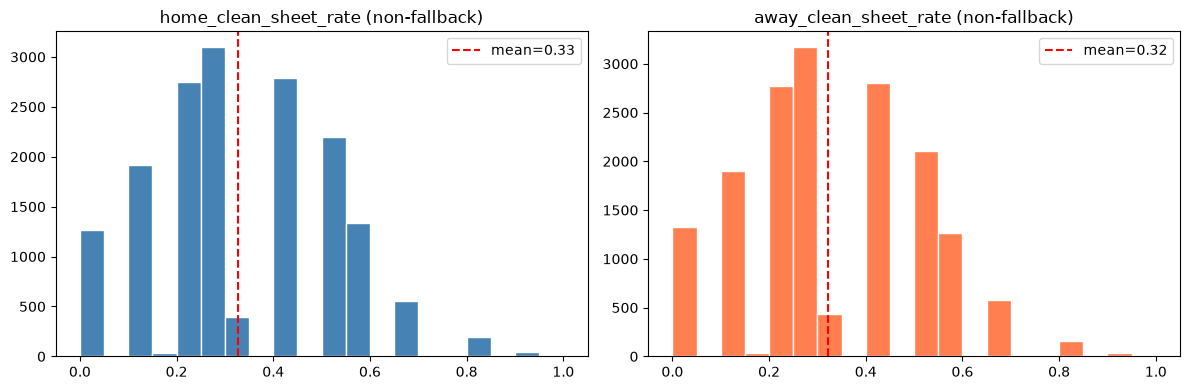

WC 2026 clean sheet rate:
       home_clean_sheet_rate  away_clean_sheet_rate
count              28.000000              28.000000
mean                0.464286               0.496429
std                 0.174726               0.181521
min                 0.100000               0.200000
25%                 0.400000               0.400000
50%                 0.450000               0.500000
75%                 0.500000               0.600000
max                 1.000000               0.900000


In [39]:
import matplotlib.pyplot as plt

# Exclude fallback rows (== 0.22 exactly)
real_h = features_v7[features_v7['home_clean_sheet_rate'] != 0.22]['home_clean_sheet_rate']
real_a = features_v7[features_v7['away_clean_sheet_rate'] != 0.22]['away_clean_sheet_rate']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, color, label in zip(
    axes,
    [real_h, real_a],
    ['steelblue', 'coral'],
    ['home_clean_sheet_rate', 'away_clean_sheet_rate']
):
    ax.hist(data, bins=20, color=color, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--',
               label=f'mean={data.mean():.2f}')
    ax.set_title(f'{label} (non-fallback)')
    ax.legend()

plt.tight_layout()
plt.show()

# WC 2026 test set
test7 = features_v7[features_v7['date'] >= '2026-06-11']
print('WC 2026 clean sheet rate:')
print(test7[['home_clean_sheet_rate', 'away_clean_sheet_rate']].describe())

In [40]:
features_v7.to_csv('../data/processed/features_v7.csv', index=False)
print('Saved features_v7.csv:', features_v7.shape)

Saved features_v7.csv: (16610, 19)


In [41]:
FEATURE_COLS_V7 = FEATURE_COLS_V1 + ['home_clean_sheet_rate', 'away_clean_sheet_rate']

train7 = features_v7[features_v7['date'] < '2022-11-20'].copy()
val7   = features_v7[
    (features_v7['date'] >= '2022-11-20') &
    (features_v7['date'] <= '2022-12-18') &
    (features_v7['tournament'] == 'FIFA World Cup')
].copy()
test7  = features_v7[features_v7['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train7)}, Val: {len(val7)}, Test: {len(test7)}')

le7 = LabelEncoder()
le7.fit(features_v7['tournament'])
for df in (train7, val7, test7):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le7.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

xgb_v1f = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1f.fit(train7[FEATURE_COLS_V1], train7['label'],
             eval_set=[(val7[FEATURE_COLS_V1], val7['label'])], verbose=False)

xgb_v7 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v7.fit(train7[FEATURE_COLS_V7], train7['label'],
            eval_set=[(val7[FEATURE_COLS_V7], val7['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [10:41:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


In [42]:
r_v1f = evaluate(xgb_v1f, val7[FEATURE_COLS_V1], test7[FEATURE_COLS_V1], val7['label'], test7['label'])
r_v7  = evaluate(xgb_v7,  val7[FEATURE_COLS_V7], test7[FEATURE_COLS_V7], val7['label'], test7['label'])

print('='*64)
print(f'{"Metric":<22} {"XGB v1 (baseline)":>20} {"XGB v7 (+clean sht)":>18}')
print('-'*64)
print(f'{"Val log loss":<22} {r_v1f["val_logloss"]:>20.4f} {r_v7["val_logloss"]:>18.4f}')
print(f'{"Test log loss":<22} {r_v1f["test_logloss"]:>20.4f} {r_v7["test_logloss"]:>18.4f}')
print(f'{"Val accuracy":<22} {r_v1f["val_acc"]:>20.1%} {r_v7["val_acc"]:>18.1%}')
print(f'{"Test accuracy":<22} {r_v1f["test_acc"]:>20.1%} {r_v7["test_acc"]:>18.1%}')
print(f'{"Best iteration":<22} {r_v1f["best_iter"]:>20} {r_v7["best_iter"]:>18}')
print('='*64)

delta_val  = r_v7['val_logloss']  - r_v1f['val_logloss']
delta_test = r_v7['test_logloss'] - r_v1f['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

print('\n── Summary: all experiments ──')
print(f'{"Model":<32} {"Val LL":>8} {"Test LL":>9} {"BestIter":>10}')
print('-'*61)
rows = [
    ('XGB v1 (baseline, 11 feats)',   r_v1f['val_logloss'], r_v1f['test_logloss'], r_v1f['best_iter']),
    ('XGB v2 (+goals_trend)',          1.0232,               0.9826,               55),
    ('XGB v3 (+days_rest raw)',        1.0212,               0.9900,               55),
    ('XGB v4 (+days_rest cap14)',      1.0206,               0.9865,               57),
    ('XGB v5 (+H2H)',                  1.0128,               0.9742,               90),
    ('XGB v6 (+ELO momentum)',         1.0215,               0.9861,               62),
    ('XGB v7 (+clean sheet rate)',    r_v7['val_logloss'],  r_v7['test_logloss'],  r_v7['best_iter']),
    ('Ensemble XGB+Poisson (prod)',    1.0188,               0.9796,               '—'),
]
for name, vl, tl, bi in rows:
    print(f'{name:<32} {vl:>8.4f} {tl:>9.4f} {str(bi):>10}')

Metric                    XGB v1 (baseline) XGB v7 (+clean sht)
----------------------------------------------------------------
Val log loss                         1.0189             1.0215
Test log loss                        0.9843             0.9838
Val accuracy                          46.9%              45.3%
Test accuracy                         53.6%              53.6%
Best iteration                           87                 63

Δ val log loss:  +0.0027  (worse)
Δ test log loss: -0.0005  (better)

── Summary: all experiments ──
Model                              Val LL   Test LL   BestIter
-------------------------------------------------------------
XGB v1 (baseline, 11 feats)        1.0189    0.9843         87
XGB v2 (+goals_trend)              1.0232    0.9826         55
XGB v3 (+days_rest raw)            1.0212    0.9900         55
XGB v4 (+days_rest cap14)          1.0206    0.9865         57
XGB v5 (+H2H)                      1.0128    0.9742         90
XGB v6 (+ELO m

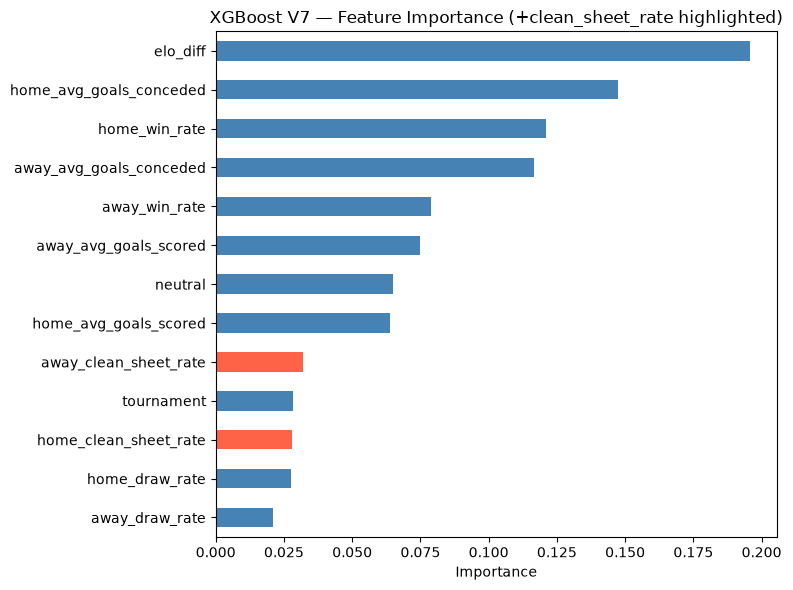

Feature importance rank:
   1. elo_diff                            0.1959
   2. home_avg_goals_conceded             0.1475
   3. home_win_rate                       0.1211
   4. away_avg_goals_conceded             0.1165
   5. away_win_rate                       0.0787
   6. away_avg_goals_scored               0.0750
   7. neutral                             0.0648
   8. home_avg_goals_scored               0.0637
   9. away_clean_sheet_rate               0.0320 ← clean sheet
  10. tournament                          0.0285
  11. home_clean_sheet_rate               0.0278 ← clean sheet
  12. home_draw_rate                      0.0276
  13. away_draw_rate                      0.0209


In [43]:
importance7 = pd.Series(
    xgb_v7.feature_importances_,
    index=FEATURE_COLS_V7
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'clean' in name else 'steelblue' for name in importance7.index]
importance7.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V7 — Feature Importance (+clean_sheet_rate highlighted)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Feature importance rank:')
for i, (name, val) in enumerate(importance7.sort_values(ascending=False).items(), 1):
    marker = ' ← clean sheet' if 'clean' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')

---
## Feature 6 — Quality-Adjusted Win Rate

**Hypothesis:** A win against Germany (ELO 1900) should count more than a win against
Andorra (ELO 1100). Raw `win_rate` treats both equally.
This is the root cause of the Saudi Arabia anomaly found in Feature 5:
their clean sheet rate looked elite because they played weak AFC opponents.

**Formula:** For each of the last 10 competitive matches, multiply the result
(win=1, draw=0.5, loss=0) by the opponent's ELO weight (`opp_elo / 1500`).
Average over N matches:

```
qa_form = Σ (result × opp_elo / 1500) / N
```

Beating a 1800-ELO team contributes 1.2, drawing with them 0.6, losing 0.
All ELO values are taken at the time of each historical match — no lookahead.

**Note:** Uses `features` (which already has `home_elo`/`away_elo`) instead of
`df_comp` — avoids a separate ELO join.

**New columns:** `home_qa_form`, `away_qa_form`  
**Saved to:** `data/processed/features_v8.csv`

In [46]:
# Compute average ELO dynamically — used as normalization factor
_all_elo  = pd.concat([features["home_elo"], features["away_elo"]])
_AVG_ELO  = round(_all_elo.mean(), 1)
_MED_ELO  = round(_all_elo.median(), 0)
print(f"Average ELO in dataset: mean={_AVG_ELO}, median={_MED_ELO:.0f}")

# Dynamic fallback: average qa_form across all competitive matches
_home_qa = (
    features["result"].map({"home_win": 1.0, "draw": 0.5, "away_win": 0.0})
    * features["away_elo"] / _AVG_ELO
).mean()
_away_qa = (
    features["result"].map({"home_win": 0.0, "draw": 0.5, "away_win": 1.0})
    * features["home_elo"] / _AVG_ELO
).mean()
_QA_FALLBACK = round((_home_qa + _away_qa) / 2, 3)
print(f"QA fallback: home={_home_qa:.3f}, away={_away_qa:.3f}, avg={_QA_FALLBACK}")


def get_qa_form(team: str, date: pd.Timestamp, n: int = 10, min_matches: int = 3) -> float:
    """Quality-adjusted form: (result × opp_elo / avg_elo) averaged over last N matches.
    result: win=1.0, draw=0.5, loss=0.0. Weight=1.0 for an average-ELO opponent.
    """
    mask = (
        ((features["home_team"] == team) | (features["away_team"] == team)) &
        (features["date"] < date)
    )
    recent = features[mask].tail(n)

    if len(recent) < min_matches:
        return _QA_FALLBACK

    score = 0.0
    for _, row in recent.iterrows():
        if row["home_team"] == team:
            points  = 1.0 if row["result"] == "home_win" else (0.5 if row["result"] == "draw" else 0.0)
            opp_elo = row["away_elo"]
        else:
            points  = 1.0 if row["result"] == "away_win" else (0.5 if row["result"] == "draw" else 0.0)
            opp_elo = row["home_elo"]
        score += points * (opp_elo / _AVG_ELO)

    return score / len(recent)


# Sanity checks — compare qa_form vs raw win_rate
print()
print(f"{chr(84)}eam                    qa_form  raw_win_rate")
print("-" * 45)
checks = [
    ("Brazil",       pd.Timestamp("2022-11-20")),
    ("Argentina",    pd.Timestamp("2022-11-20")),
    ("Saudi Arabia", pd.Timestamp("2022-11-20")),
    ("Germany",      pd.Timestamp("2022-11-20")),
    ("France",       pd.Timestamp("2022-11-20")),
]
for team, date in checks:
    qa   = get_qa_form(team, date)
    mask = ((features["home_team"]==team)|(features["away_team"]==team)) & (features["date"]<date)
    raw  = features[mask].tail(10).apply(
        lambda r: 1.0 if (r["home_team"]==team and r["result"]=="home_win") or
                         (r["away_team"]==team and r["result"]=="away_win") else 0.0, axis=1
    ).mean()
    print(f"{team:<20} {qa:>10.3f}  {raw:>10.3f}")


Average ELO in dataset: mean=1605.2, median=1500
QA fallback: home=0.587, away=0.391, avg=0.489

Team                    qa_form  raw_win_rate
---------------------------------------------
Brazil                    0.900       0.700
Argentina                 0.915       0.700
Saudi Arabia              0.784       0.700
Germany                   0.687       0.500
France                    0.666       0.500


In [47]:
# ~2-3 minutes
from tqdm.auto import tqdm

home_qa, away_qa = [], []
for _, row in tqdm(features.iterrows(), total=len(features), desc='QA form'):
    home_qa.append(get_qa_form(row['home_team'], row['date']))
    away_qa.append(get_qa_form(row['away_team'], row['date']))

features_v8 = features.copy()
features_v8['home_qa_form'] = home_qa
features_v8['away_qa_form'] = away_qa

print('features_v8 shape:', features_v8.shape)
print(features_v8[['home_qa_form', 'away_qa_form']].describe())

# Correlation with raw win_rate (how much new info?)
corr_h = features_v8['home_qa_form'].corr(features_v8['home_win_rate'])
corr_a = features_v8['away_qa_form'].corr(features_v8['away_win_rate'])
print(f'\nCorrelation with raw win_rate:')
print(f'  home: {corr_h:.3f}')
print(f'  away: {corr_a:.3f}')

QA form: 100%|██████████| 16610/16610 [02:47<00:00, 99.46it/s] 

features_v8 shape: (16610, 19)
       home_qa_form  away_qa_form
count  16610.000000  16610.000000
mean       0.492672      0.486807
std        0.213668      0.211713
min        0.000000      0.000000
25%        0.344389      0.339849
50%        0.508348      0.495717
75%        0.654023      0.641229
max        1.074446      1.107235

Correlation with raw win_rate:
  home: 0.919
  away: 0.910


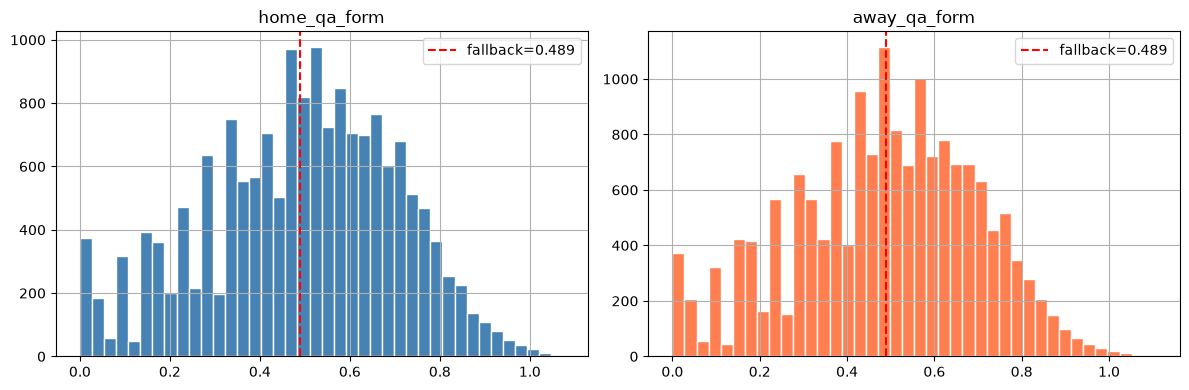

WC 2026 qa_form vs win_rate comparison (sample):
  home_team  home_qa_form  home_win_rate              away_team  away_qa_form  away_win_rate
     Mexico      0.844381            0.8           South Africa      0.560678            0.5
South Korea      0.764173            0.6                Czechia      0.619424            0.5
     Canada      0.634095            0.5 Bosnia and Herzegovina      0.665680            0.5
        USA      0.612011            0.6               Paraguay      0.761400            0.5
  Australia      0.695895            0.5                Türkiye      0.815412            0.8
      Haiti      0.420508            0.3               Scotland      0.728943            0.7
      Qatar      0.543920            0.5            Switzerland      0.591079            0.4
     Brazil      0.682781            0.5                Morocco      0.860142            0.8


In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes,
    ['home_qa_form', 'away_qa_form'], ['steelblue', 'coral']):
    features_v8[col].hist(bins=40, ax=ax, color=color, edgecolor='white')
    ax.axvline(_QA_FALLBACK, color='red', linestyle='--', label=f'fallback={_QA_FALLBACK}')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

# WC 2026 — does qa_form separate teams better than raw win_rate?
test8 = features_v8[features_v8['date'] >= '2026-06-11'].copy()
print('WC 2026 qa_form vs win_rate comparison (sample):')
print(test8[['home_team','home_qa_form','home_win_rate',
              'away_team','away_qa_form','away_win_rate']].head(8).to_string(index=False))

In [49]:
features_v8.to_csv('../data/processed/features_v8.csv', index=False)
print('Saved features_v8.csv:', features_v8.shape)

Saved features_v8.csv: (16610, 19)


In [50]:
FEATURE_COLS_V8 = FEATURE_COLS_V1 + ['home_qa_form', 'away_qa_form']

train8 = features_v8[features_v8['date'] < '2022-11-20'].copy()
val8   = features_v8[
    (features_v8['date'] >= '2022-11-20') &
    (features_v8['date'] <= '2022-12-18') &
    (features_v8['tournament'] == 'FIFA World Cup')
].copy()
test8  = features_v8[features_v8['date'] >= '2026-06-11'].copy()

print(f'Train: {len(train8)}, Val: {len(val8)}, Test: {len(test8)}')

le8 = LabelEncoder()
le8.fit(features_v8['tournament'])
for df in (train8, val8, test8):
    df['neutral']    = df['neutral'].astype(int)
    df['tournament'] = le8.transform(df['tournament'])
    df['label']      = df['result'].map(RESULT_MAP)

xgb_v1g = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v1g.fit(train8[FEATURE_COLS_V1], train8['label'],
             eval_set=[(val8[FEATURE_COLS_V1], val8['label'])], verbose=False)

xgb_v8 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    early_stopping_rounds=20, random_state=42,
)
xgb_v8.fit(train8[FEATURE_COLS_V8], train8['label'],
            eval_set=[(val8[FEATURE_COLS_V8], val8['label'])], verbose=False)

print('Training done.')

Train: 14639, Val: 64, Test: 28


/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [11:26:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/bony-macpro/Documents/BeCode/Projects/World-Cup-Match-Prediction/.worldcupfootball/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [11:26:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Training done.


In [51]:
r_v1g = evaluate(xgb_v1g, val8[FEATURE_COLS_V1], test8[FEATURE_COLS_V1], val8['label'], test8['label'])
r_v8  = evaluate(xgb_v8,  val8[FEATURE_COLS_V8], test8[FEATURE_COLS_V8], val8['label'], test8['label'])

print('='*64)
print(f'{"Metric":<22} {"XGB v1 (baseline)":>20} {"XGB v8 (+qa_form)":>18}')
print('-'*64)
print(f'{"Val log loss":<22} {r_v1g["val_logloss"]:>20.4f} {r_v8["val_logloss"]:>18.4f}')
print(f'{"Test log loss":<22} {r_v1g["test_logloss"]:>20.4f} {r_v8["test_logloss"]:>18.4f}')
print(f'{"Val accuracy":<22} {r_v1g["val_acc"]:>20.1%} {r_v8["val_acc"]:>18.1%}')
print(f'{"Test accuracy":<22} {r_v1g["test_acc"]:>20.1%} {r_v8["test_acc"]:>18.1%}')
print(f'{"Best iteration":<22} {r_v1g["best_iter"]:>20} {r_v8["best_iter"]:>18}')
print('='*64)

delta_val  = r_v8['val_logloss']  - r_v1g['val_logloss']
delta_test = r_v8['test_logloss'] - r_v1g['test_logloss']
print(f'\nΔ val log loss:  {delta_val:+.4f}  ({"better" if delta_val < 0 else "worse"})')
print(f'Δ test log loss: {delta_test:+.4f}  ({"better" if delta_test < 0 else "worse"})')

print('\n── Summary: all experiments ──')
print(f'{"Model":<34} {"Val LL":>8} {"Test LL":>9} {"BestIter":>10}')
print('-'*63)
rows = [
    ('XGB v1 (baseline, 11 feats)',   r_v1g['val_logloss'], r_v1g['test_logloss'], r_v1g['best_iter']),
    ('XGB v2 (+goals_trend)',          1.0232,               0.9826,               55),
    ('XGB v3 (+days_rest raw)',        1.0212,               0.9900,               55),
    ('XGB v4 (+days_rest cap14)',      1.0206,               0.9865,               57),
    ('XGB v5 (+H2H)',                  1.0128,               0.9742,               90),
    ('XGB v6 (+ELO momentum)',         1.0215,               0.9861,               62),
    ('XGB v7 (+clean sheet rate)',     1.0215,               0.9838,               63),
    ('XGB v8 (+qa_form)',             r_v8['val_logloss'],  r_v8['test_logloss'],  r_v8['best_iter']),
    ('Ensemble XGB+Poisson (prod)',    1.0188,               0.9796,               '—'),
]
for name, vl, tl, bi in rows:
    print(f'{name:<34} {vl:>8.4f} {tl:>9.4f} {str(bi):>10}')

Metric                    XGB v1 (baseline)  XGB v8 (+qa_form)
----------------------------------------------------------------
Val log loss                         1.0189             1.0262
Test log loss                        0.9843             1.0047
Val accuracy                          46.9%              45.3%
Test accuracy                         53.6%              53.6%
Best iteration                           87                 55

Δ val log loss:  +0.0073  (worse)
Δ test log loss: +0.0205  (worse)

── Summary: all experiments ──
Model                                Val LL   Test LL   BestIter
---------------------------------------------------------------
XGB v1 (baseline, 11 feats)          1.0189    0.9843         87
XGB v2 (+goals_trend)                1.0232    0.9826         55
XGB v3 (+days_rest raw)              1.0212    0.9900         55
XGB v4 (+days_rest cap14)            1.0206    0.9865         57
XGB v5 (+H2H)                        1.0128    0.9742         90
XG

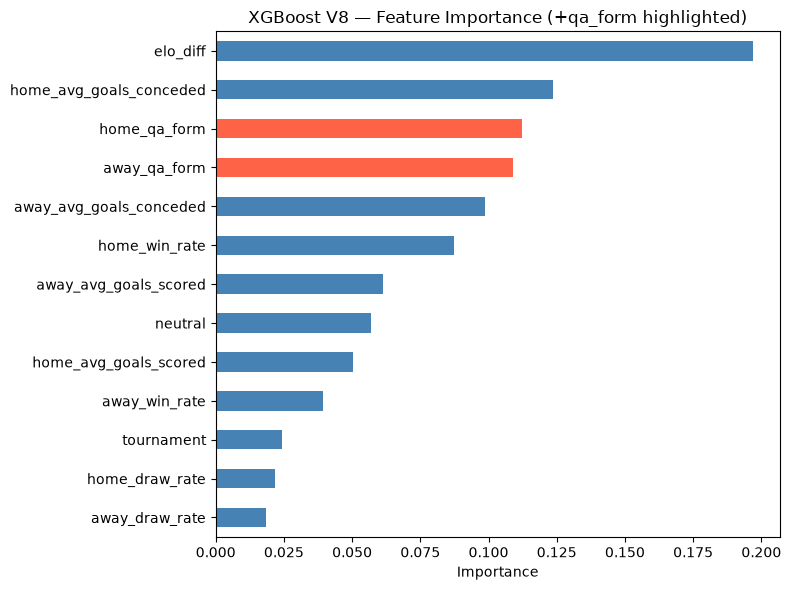

Feature importance rank:
   1. elo_diff                            0.1970
   2. home_avg_goals_conceded             0.1236
   3. home_qa_form                        0.1123 ← QA form
   4. away_qa_form                        0.1090 ← QA form
   5. away_avg_goals_conceded             0.0989
   6. home_win_rate                       0.0875
   7. away_avg_goals_scored               0.0612
   8. neutral                             0.0568
   9. home_avg_goals_scored               0.0502
  10. away_win_rate                       0.0393
  11. tournament                          0.0241
  12. home_draw_rate                      0.0216
  13. away_draw_rate                      0.0185


In [52]:
importance8 = pd.Series(
    xgb_v8.feature_importances_,
    index=FEATURE_COLS_V8
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if 'qa' in name else 'steelblue' for name in importance8.index]
importance8.plot(kind='barh', ax=ax, color=colors)
ax.set_title('XGBoost V8 — Feature Importance (+qa_form highlighted)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Feature importance rank:')
for i, (name, val) in enumerate(importance8.sort_values(ascending=False).items(), 1):
    marker = ' ← QA form' if 'qa' in name else ''
    print(f'  {i:2}. {name:<35} {val:.4f}{marker}')